# Iris Classification

This notebook demonstrates a reproducible classification workflow using the Iris dataset and logistic regression.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay
from model import load_data, split_data, scale_data, train_model, evaluate_model


## 1. Load the dataset
The Iris dataset is bundled with scikit-learn, so the project does not depend on an external download.


In [21]:
X, y, target_names = load_data()
print("Feature matrix shape:", X.shape)
print("Target names:", target_names)
X.head()


Feature matrix shape: (150, 4)
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. Inspect the data


In [24]:
data = X.copy()
data["species"] = [target_names[i] for i in y]
data.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [26]:
data["species"].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Visualize two important features


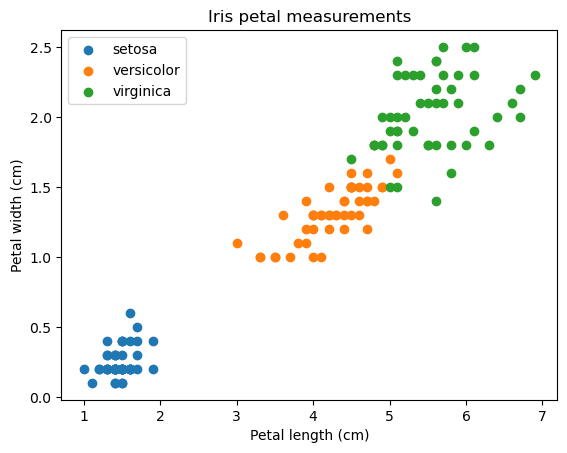

In [29]:
for species in target_names:
    subset = data[data["species"] == species]
    plt.scatter(subset["petal length (cm)"], subset["petal width (cm)"], label=species)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris petal measurements")
plt.legend()
plt.show()


## 4. Split and standardize the data
We use a fixed random seed to make the experiment reproducible.


In [31]:
X_train, X_test, y_train, y_test = split_data(X, y)
X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test)
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 120
Test samples: 30


## 5. Train logistic regression


In [35]:
model = train_model(X_train_scaled, y_train)
print(model)


LogisticRegression(max_iter=500, random_state=42)


## 6. Evaluate the model


In [38]:
predictions, accuracy, matrix, report = evaluate_model(model, X_test_scaled, y_test)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification report:")
print(report)


Accuracy: 0.9333

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 7. Confusion matrix


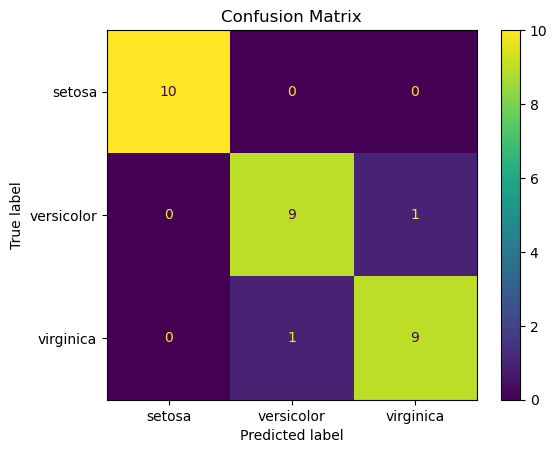

In [41]:
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=target_names)
display.plot()
plt.title("Confusion Matrix")
plt.show()


## 8. Compare predictions with true labels


In [44]:
results = pd.DataFrame({
    "true_label": [target_names[i] for i in y_test],
    "predicted_label": [target_names[i] for i in predictions]
})
results.head(10)


,true_label,predicted_label
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor
